# Titanic Reworked

### Preprocessing data

In [1]:
import pandas as pd

titanic_df = pd.read_csv('usethistitanic.csv')

In [2]:
titanic_df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
titanic_df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [4]:
titanic_df = titanic_df.dropna(subset=['fare'])

In [5]:
median_age = titanic_df['age'].median()
titanic_df['age'] = titanic_df['age'].fillna(median_age)

In [6]:
titanic_df['sex'] = titanic_df['sex'].map({'male': 1, 'female': 0})
titanic_df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [7]:
titanic_df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
cabin        1013
embarked        2
boat          822
body         1188
home.dest     563
dtype: int64

### Remember that the logistic regression is a classifier as well. Name this first model model1. Can you use lines 1-23 under Part 3 of W7 to run a logistic regression with gridsearchCV to predict death on the titanic.

In [8]:
from sklearn.model_selection import train_test_split

X = titanic_df[['age', 'sex', 'fare']]
y = titanic_df['survived']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Xtrain shape {Xtrain.shape}')
print(f'Xtest shape {Xtest.shape}')
print(f'ytrain shape {ytrain.shape}')
print(f'ytest shape {ytest.shape}')

Xtrain shape (1046, 3)
Xtest shape (262, 3)
ytrain shape (1046,)
ytest shape (262,)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression()

param_grid = {
    'penalty': ['l1','l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

grid_log = GridSearchCV(log_reg, param_grid, cv = 5, scoring='accuracy')
grid_log.fit(Xtrain_scaled, ytrain)

print(f'Best Penalty: {grid_log.best_params_['penalty']}')
print(f'Best C: {grid_log.best_params_['C']}')

best_log_model = grid_log.best_estimator_

Best Penalty: l1
Best C: 0.01


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

### What was the best penalty? L1 or L2? Why? Write a meaningful interpretation of the choice. What was the best C parameter? Why? Write a meaningful interpretation of the choice.

the best penalty was l1 meaning lasso. this means that the model is scaling the weights of some features all the way down to 0, similar to the spotify dataset below, this confuses me because there are so few features being used. the best C parameter was 0.01 where the model balances over vs underfitting


### Now use the appropriate metrics for logistic regression to see how your model did. This includes accuracy, AUC/ROC, and others you may have learned (precision/recall). Make a choice regarding which metric is the most appropriate for death prediction, justify your choice in metric. Analyze your results.

In [11]:
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 

ypred = best_log_model.predict(Xtest_scaled)

print(f'precision {precision_score(ytest, ypred)}')
print(f'recall {recall_score(ytest, ypred)}')
print(f'accuracy {accuracy_score(ytest, ypred)}')
print(f'f1 score {f1_score(ytest, ypred)}')


precision 0.7204301075268817
recall 0.6320754716981132
accuracy 0.7519083969465649
f1 score 0.6733668341708543


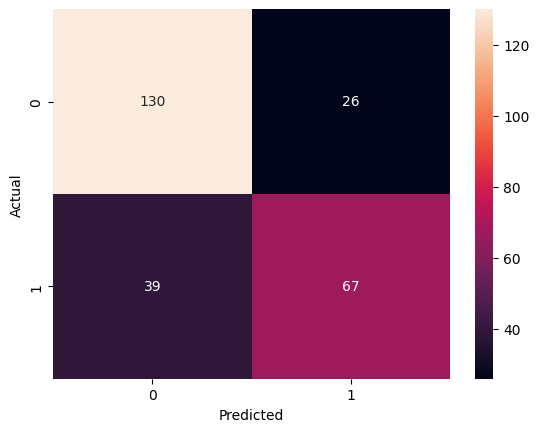

In [12]:
cm = confusion_matrix(ytest, ypred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


0.7327044025157233


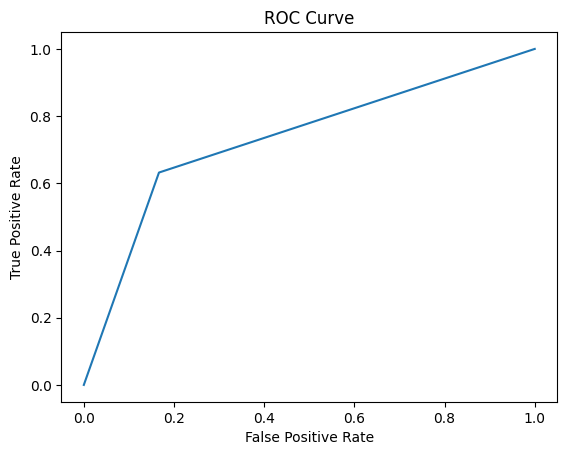

In [13]:
probs = best_log_model.predict_proba(Xtest_scaled)[:, 1]
auc = roc_auc_score(ytest, probs)
fpr, tpr, thresholds = roc_curve(ytest, probs)

print(auc)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


recall is the most important because I am taking the position of a diver. it is okay is I bring a few dead people back as long as I still brought every survivor back. It would be a lot worse If I was falsely predicting living people were dead and did not take them back.

#### Given what we are trying to predict (death or survival), do you think it is appropriate to use a linear regression instead of a logistic one? Why or why not?

linear regression is not appropiate to use instead of a classifier. with the titanic dataset we are aiming to make a binary prediction, the person either survived or died. linear regression focuses on predicting any numerical value which is not useful in this case.

# Spotify Dataset

### We used linear regression to predict danceability the first time around on W4. Take a look at your columns again. Make a meaningful choice of 3 columns that you think may predict danceability a bit better this time for when you split your data.

In [14]:
df_spotify = pd.read_csv('top2019.csv')

In [15]:
df_spotify.head()

,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,6v3KW9xbzN5yKLt9YKDYA,Señorita,Shawn Mendes,0.759,0.548,9.0,-6.049,0.0,0.0290,0.0392,0.00,0.0828,0.749,116.967,190800.0,4.0
1,2Fxmhks0bxGSBdJ92vM42,bad guy,Billie Eilish,0.701,0.425,7.0,-10.965,1.0,0.3750,0.3280,0.13,0.1000,0.562,135.128,194088.0,4.0
2,0RiRZpuVRbi7oqRdSMwhQ,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.755,0.522,2.0,-4.368,1.0,0.0575,0.5330,0.00,0.0685,0.925,89.960,157560.0,4.0
3,6ocbgoVGwYJhOv1GgI9Ns,7 rings,Ariana Grande,0.778,0.317,1.0,-10.732,0.0,0.3340,0.5920,0.00,0.0881,0.327,140.048,178627.0,4.0
4,2YpeDb67231RjR0MgVLzs,Old Town Road - Remix,Lil Nas X,0.878,0.619,6.0,-5.560,1.0,0.1020,0.0533,0.00,0.1130,0.639,136.041,157067.0,4.0


In [16]:
Xs = df_spotify[['energy', 'tempo', 'instrumentalness']]
ys = df_spotify['danceability']

In [17]:
Xtrains, Xtests, ytrains, ytests = train_test_split(X, y, test_size=0.2, random_state=0)
scalers = StandardScaler()

Xtrain_scaleds = scalers.fit_transform(Xtrains)
Xtest_scaleds = scalers.transform(Xtests)

### Use part 5 on W7 to run a regression that allows use of gridsearchCV to run a lasso regression on danceability. What were your best parameters? Interpret your results.

In [25]:


log_regs = LogisticRegression()

param_grids = {
    'penalty': ['l1'], #l1 is lasso
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

grid_logs = GridSearchCV(log_regs, param_grids, cv = 5, scoring='accuracy')
grid_logs.fit(Xtrain_scaleds, ytrains)

print(f'Best Penalty: {grid_logs.best_params_['penalty']}')
print(f'Best C: {grid_logs.best_params_['C']}')
print(f'Best Score: {grid_logs.best_score_}')

best_log_models = grid_logs.best_estimator_

Best Penalty: l1
Best C: 0.01
Best Score: 0.7782228298017771


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

### Use part 5 on W7 to run a regression that allows use of gridsearchCV to run a ridge regression on danceability. What were your best parameters? Interpret your results.


In [26]:
param_grids1 = {
    'penalty': ['l2'], #l2 is ridge
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

grid_logs1 = GridSearchCV(log_regs, param_grids1, cv = 5, scoring='accuracy')
grid_logs1.fit(Xtrain_scaleds, ytrains)

print(f'Best Penalty: {grid_logs1.best_params_['penalty']}')
print(f'Best C: {grid_logs1.best_params_['C']}')
print(f'Best Score: {grid_logs1.best_score_}')

best_log_models1 = grid_logs1.best_estimator_

Best Penalty: l2
Best C: 0.01
Best Score: 0.7705764411027569


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

I could have done an interpretation after each question but im just going to do one cell about both for no reason other than the fact that Im having difficulty scrolling. Anyhow... it seems the best c parameter for both lasso and ridge is 0.01. this means that a c of 0.01 is where regularization is balanced for this dataset so that it is not over or underfitted to th trainging data. outside of that, the l1 penalty (lasso) model preformed slightly better in terms of accuracy with whopping ~0.008 higher score. this means the logistic regression model preforms better when reducing some features all the way to zero, which im not entirely sure it actually did considering there were only 3 features used.